This notebook applies the Conveyal Estimated LTS framework (Conveyal 2015; Mekuria et al. 2012), augmented by Jeong & Smith (2025), to the **Belfast** road network.

It uses the pre-computed NI-wide LTS-labelled network (`ni_cycling_network_lts.parquet`) and clips it to the Belfast Local Government District boundary, avoiding the need to re-run the full OSM extraction and LTS pipeline.

**Purpose:** produce a Belfast-specific LTS network for downstream Conveyal analysis, routing, and accessibility modelling.

## Methodology overview

The NI-wide pipeline (see `ni_cycle_lts_assessment.ipynb`) implements three core stages:

1. **OSM network extraction** — download the full road network via OSMnx, filter to cyclable highway types, and save as GeoParquet
2. **Cycle infrastructure classification** — derive 6 categories (Protected a/b/c, Unprotected Mandatory, Unprotected Advisory, Off-Road) from OSM tags following Jeong & Smith (2025) Table 1
3. **Level of Traffic Stress (LTS)** — augmented Conveyal-based scheme with Routino fallback, cycle infrastructure override, and signalised junction adjustment

This notebook **clips the result** to Belfast LGD and reproduces the visualisation and export steps.

## References

- Jeong, P. & Smith, D. (2025). *Improving Infrastructure and Accessibility Indicators for Urban Cycling Networks.* CASA Working Paper 242.
- Mekuria, M. C., Furth, P. G., & Nixon, H. (2012). *Low-Stress Bicycling and Network Connectivity.* MTI Report 11-19.
- Conveyal (2015). *Cycling Level of Traffic Stress.*
- Department for Transport (2020). *LTN 1/20: Cycle Infrastructure Design.*

## Environment setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import json
from pathlib import Path

import re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point, LineString, Polygon

# Network analysis
import networkx as nx
import igraph as ig

# OSM
import pyrosm
import osmnx as ox
ox.settings.use_cache = True
ox.settings.log_console = False

# H3 for hexagonal aggregation
import h3

# Project paths
DATA_DIR = Path('../Data')
OUTPUT_DIR = Path('../Figure')
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# Coordinate reference systems
CRS_WGS84 = 'EPSG:4326'    # OSM native
CRS_IG    = 'EPSG:29903'   # Irish Grid

print('Environment ready.')
print(f"Working directory: {os.getcwd()}")


Environment ready.
Working directory: G:\我的云端硬盘\PCTNI\Code


## Study area — Belfast LGD

Filter the NI Super Data Zones (SDZ) to Belfast Local Government District.
All spatial operations use Irish Grid (EPSG:29903).

In [2]:
# Load NI Super Data Zones and filter to Belfast LGD
raw_data = gpd.read_file('../Data/zones_sdz.gpkg', engine='pyogrio')
raw_data = raw_data.to_crs(CRS_IG)

# Identify Belfast — check exact LGD name
print('Available LGDs:', sorted(raw_data['lgd2014_nm'].unique()))

# Filter to Belfast
belfast_zones = raw_data[raw_data['lgd2014_nm'] == 'Belfast'].copy()

# Create a dissolved union for spatial operations
belfast_boundary = belfast_zones.unary_union

print(f'Belfast SDZ zones: {len(belfast_zones)}')
print(f'Belfast area: {belfast_zones.geometry.area.sum() / 1e6:.1f} km²')


Available LGDs: ['Antrim and Newtownabbey', 'Ards and North Down', 'Armagh City, Banbridge and Craigavon', 'Belfast', 'Causeway Coast and Glens', 'Derry City and Strabane', 'Fermanagh and Omagh', 'Lisburn and Castlereagh', 'Mid Ulster', 'Mid and East Antrim', 'Newry, Mourne and Down']
Belfast SDZ zones: 175
Belfast area: 137.7 km²


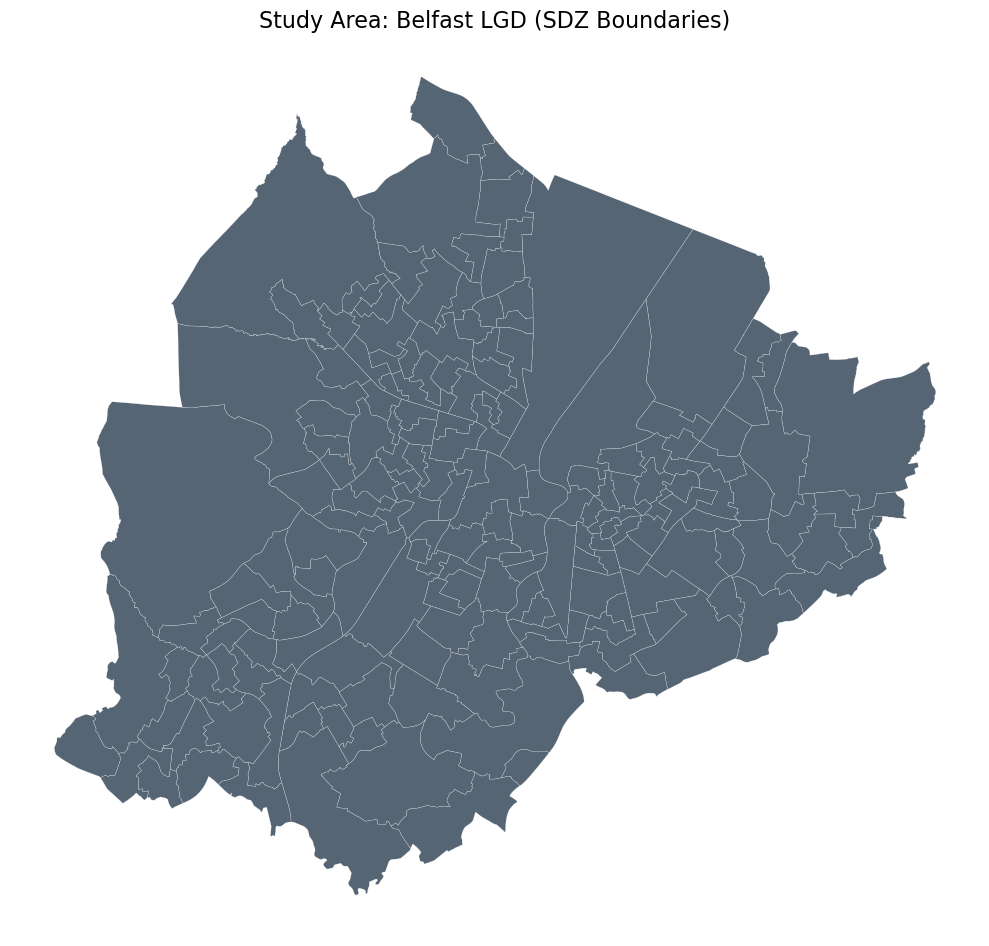

In [3]:
fig, ax = plt.subplots(figsize=(10, 10))
belfast_zones.plot(ax=ax, edgecolor='white', linewidth=0.2,
                   facecolor='#2c3e50', alpha=0.8)
ax.set_title('Study Area: Belfast LGD (SDZ Boundaries)', fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()


## Extract the OSM road network

The full road network is extracted via OSMnx using the study area polygon, with
`network_type='all'` because Northern Ireland has very few edges with dedicated
cycling tags — using `'cycling'` returns near-zero results. Key cycling-relevant
OSM tags (`cycleway`, `cycleway:left/right/both`, `bicycle`, `surface`,
`segregated`, `lit`) are requested via `ox.settings.useful_tags_way` to ensure
the infrastructure classification and LTS pipeline have complete attribute
coverage.

After extraction, edges are reprojected to Irish Grid (EPSG:29903) and saved as
GeoParquet. Subsequent runs load directly from the cached file.

> **Data version:** OSM data retrieved via Overpass API on 2025-05-07, containing
> all edits up to 2025-05-07T20:21:31Z.

In [5]:
# ── Study area setup ────────────────────────────────────────────────────────
# Alias belfast_zones as study_area for reusability across the pipeline
study_area = belfast_zones.copy()

# ── Bounding box for OSM extraction ──────────────────────────────────────────
# pyrosm expects [minx, miny, maxx, maxy] in EPSG:4326
study_area_4326 = study_area.to_crs("EPSG:4326")
bbox = list(study_area_4326.total_bounds)
print(f"Bounding box (WGS84): {[round(x, 4) for x in bbox]}")

# ── Load OSM PBF ──────────────────────────────────────────────────────────────
PBF_PATH = Path(DATA_DIR / "northern_ireland_only.pbf") 
assert PBF_PATH.exists(), f"PBF file not found: {PBF_PATH}"

osm = pyrosm.OSM(str(PBF_PATH), bounding_box=bbox)

# ── Extract cycling network ───────────────────────────────────────────────────
# network_type='cycling' includes roads accessible to cyclists
# extra_attributes pulls LTS-relevant OSM tags
edges = osm.get_network(
    network_type='cycling',
    extra_attributes=[
        'cycleway', 'cycleway:left', 'cycleway:right', 'cycleway:both',
        'bicycle', 'foot', 'maxspeed', 'lanes', 'oneway', 'surface',
        'segregated', 'lit', 'access',
    ]
)

# ── Reproject and clip to Belfast boundary ────────────────────────────────────
if edges is not None:
    print(f"Raw edges extracted: {len(edges):,}")

    # Irish Transverse Mercator (EPSG:2157) — correct CRS for Northern Ireland
    edges = edges.to_crs("EPSG:2157")
    belfast_boundary_itm = study_area.to_crs("EPSG:2157").unary_union

    # Clip to exact Belfast LGD boundary
    edges = gpd.clip(edges, belfast_boundary_itm)
    print(f"Edges after clipping to Belfast: {len(edges):,}")

    # ── Export ────────────────────────────────────────────────────────────────
    out_path = DATA_DIR / "cycling_network_processed.parquet"
    edges.to_parquet(out_path)
    print(f"Saved to: {out_path}")

else:
    print("WARNING: No edges extracted — check PBF path and bounding box")


Bounding box (WGS84): [np.float64(-6.0602), np.float64(54.5306), np.float64(-5.8074), np.float64(54.665)]
Raw edges extracted: 29,612
Edges after clipping to Belfast: 23,481
Saved to: ..\Data\cycling_network_processed.parquet


> To save time, the edges are saved with parquet format. Skip the chunk above read it directly! 

In [6]:
# Read the Parquet file into a GeoDataFrame
edges = gpd.read_parquet(DATA_DIR / "cycling_network_processed.parquet")

# take a look
pd.set_option('display.max_columns', None)
edges.head()


,access,bicycle,bridge,busway,cycleway,foot,footway,highway,int_ref,junction,lanes,lit,maxspeed,motorcar,motorroad,motor_vehicle,name,oneway,psv,ref,service,segregated,sidewalk,smoothness,surface,tracktype,tunnel,turn,width,cycleway:left,cycleway:right,cycleway:both,id,timestamp,version,tags,osm_type,geometry,length
29041,private,None,None,None,None,None,None,service,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,concrete,None,None,None,None,None,None,None,1487598059,1773226226,1,"{""visible"":false}",way,"MULTILINESTRING ((729638.324 867885.739, 72963...",134.0
29047,private,None,None,None,None,None,None,service,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,concrete,None,None,None,None,None,None,None,1487598065,1773226226,1,"{""visible"":false}",way,"MULTILINESTRING ((729575.164 867906.03, 729579...",34.0
29044,private,None,None,None,None,None,None,service,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,concrete,None,None,None,None,None,None,None,1487598062,1773226226,1,"{""visible"":false}",way,"MULTILINESTRING ((729499.776 867894.963, 72956...",87.0
29049,private,None,None,None,None,None,None,service,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,concrete,None,None,None,None,None,None,None,1487598067,1773226226,1,"{""visible"":false}",way,"LINESTRING (729556.028 867951.365, 729558.638 ...",19.0
29046,private,None,None,None,None,None,None,service,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,concrete,None,None,None,None,None,None,None,1487598064,1773226226,1,"{""visible"":false}",way,"MULTILINESTRING ((729482.388 867942.897, 72949...",90.0


## Cycle infrastructure classification

Before categorising cycle infrastructure, the road network dataset was checked to exclude highway types that are mis-specified, misspelled in OSM, or unsuitable for cycling. Their exclusion criteria cover motorways and motorway links (legally prohibited for cycling), busways without explicit bicycle access, segments tagged as under construction or proposed, and common OSM misspellings such as cycleway way. 

> Although there are no motorways in this dataframe (because the `network_type='cycling'` was used when extract the cycling network.), and no misspelled rows.

An inspection of the Belfast OSM data revealed additional invalid or non-cyclable highway values (steps), which were also removed. In total, 17 edges were excluded through this filtering step.

In [8]:
print(edges['highway'].value_counts().to_string())

highway
service           9602
residential       6208
path              2536
primary            881
tertiary           838
cycleway           622
unclassified       561
trunk              431
secondary          420
footway            324
living_street      318
track              256
pedestrian         208
trunk_link          92
tertiary_link       62
secondary_link      49
primary_link        48
steps               17
busway               8


In [9]:
def filter_unsuitable_highways(edges):
    """
    Pre-process road network to exclude highway types that are
    mis-specified, misspelled in OSM, or unsuitable for cycling.

    Based on Jeong & Smith (2025), extended for West Midlands data.

    Excluded categories:
    - Motorways and motorway links (legally prohibited for cycling)
    - Construction / proposed / planned (not yet built)
    - Common OSM misspellings (e.g. 'cycleway way')
    - Invalid or non-cyclable tags found in study area
      (no, steps, services, raceway, emergency_bay, bus_stop)

    Returns: filtered GeoDataFrame
    """
    exclude_exact = {
        'steps'
    }

    highway = edges['highway'].astype(str).str.strip().str.lower()

    mask_exclude = highway.isin(exclude_exact)

    n_before = len(edges)
    edges_filtered = edges[~mask_exclude].copy()
    n_after = len(edges_filtered)

    print(f"Highway filtering: {n_before} -> {n_after} edges "
          f"({n_before - n_after} removed)")

    if mask_exclude.any():
        print("\nRemoved highway types:")
        print(edges.loc[mask_exclude, 'highway'].value_counts().to_string())

    return edges_filtered

### Cycle infrastructure classification

Each road segment is classified into one of six cycle infrastructure categories based on [OSM tags](https://wiki.openstreetmap.org/wiki/Key:highway#When_cycleway_is_drawn_as_its_own_way_(see_Bicycle)):

| Category | OSM mapping |
|---|---|
| Protected Cycle Lane (a) — adjacent to road | `cycleway=track`, `cycleway:right=track`, `cycleway:left=track` |
| Protected Cycle Lane (b) — designated cycleway | `highway=cycleway` (excluding shared bus lanes) |
| Protected Cycle Lane (c) — separated cycleway | `cycleway=separate`, `cycleway=sidepath`, `bicycle=use_sidepath` |
| Unprotected Mandatory Cycle Lane | `cycleway=lane` and lane-related tags (excluding shared bus) |
| Unprotected Advisory Cycle Lane | `cycleway=advisory`, `cycleway=shared`, `cycleway=share_busway` |
| Off-Road Path | `highway=path/track/footway` + `bicycle=designated/yes` |
| (Default) Road without cycle infrastructure | Anything not matching above |

In [10]:
print(edges['cycleway'].value_counts().to_string())

cycleway
no              152
crossing        118
lane             24
share_busway     20
segregated       19
track             3
opposite          1
shared_lane       1


In [11]:
def classify_cycle_infrastructure(row):
    """
    Classify a road segment into one of 6 cycle infrastructure categories
    plus a default 'no infrastructure' class.

    Following Jeong & Smith (2025) Table 1.

    Returns: str — one of {'protected_a', 'protected_b', 'protected_c',
                            'unprotected_mandatory', 'unprotected_advisory',
                            'off_road', 'none'}
    """
    highway = row.get('highway', '')
    cycleway = row.get('cycleway', '')
    cycleway_left = row.get('cycleway:left', '')
    cycleway_right = row.get('cycleway:right', '')
    cycleway_both = row.get('cycleway:both', '')
    bicycle = row.get('bicycle', '')

    # Protected (b): dedicated cycleway as separate geometry
    if highway == 'cycleway':
        # Exclude shared bus lanes/ways
        if cycleway not in ('share_busway', 'shared_busway'):
            return 'protected_b'

    # Protected (c): cycleway physically separated from road
    if cycleway in ('separate', 'sidepath') or bicycle == 'use_sidepath':
        return 'protected_c'

    # Protected (a): track adjacent to road
    track_tags = ('track',)
    if (cycleway in track_tags
        or cycleway_left in track_tags
        or cycleway_right in track_tags
        or cycleway_both in track_tags):
        return 'protected_a'

    # Unprotected mandatory cycle lane
    lane_tags = ('lane', 'opposite_lane')
    if (cycleway in lane_tags
        or cycleway_left in lane_tags
        or cycleway_right in lane_tags
        or cycleway_both in lane_tags):
        return 'unprotected_mandatory'

    # Unprotected advisory (includes shared bus lanes)
    advisory_tags = ('advisory', 'shared', 'share_busway', 'shared_lane', 'shared_busway')
    if (cycleway in advisory_tags
        or cycleway_left in advisory_tags
        or cycleway_right in advisory_tags
        or cycleway_both in advisory_tags):
        return 'unprotected_advisory'

    # Off-road paths with bicycle access
    if highway in ('path', 'track', 'footway'):
        if bicycle in ('designated', 'yes'):
            return 'off_road'

    return 'none'


In [12]:
if edges is not None:
    # Step 1: Remove mis-specified / non-cyclable highway types
    edges = filter_unsuitable_highways(edges)

    # Step 2: Classify cycle infrastructure
    edges['cycle_infra'] = edges.apply(classify_cycle_infrastructure, axis=1)

    # Distribution check
    print("\nCycle infrastructure distribution (by edge count):")
    print(edges['cycle_infra'].value_counts())
    print(f"\n% with any cycle infrastructure: "
          f"{(edges['cycle_infra'] != 'none').mean() * 100:.1f}%")


Highway filtering: 23481 -> 23464 edges (17 removed)

Removed highway types:
highway
steps    17

Cycle infrastructure distribution (by edge count):
cycle_infra
none                     21715
protected_b                622
off_road                   428
unprotected_advisory       387
unprotected_mandatory      296
protected_c                  9
protected_a                  7
Name: count, dtype: int64

% with any cycle infrastructure: 7.5%


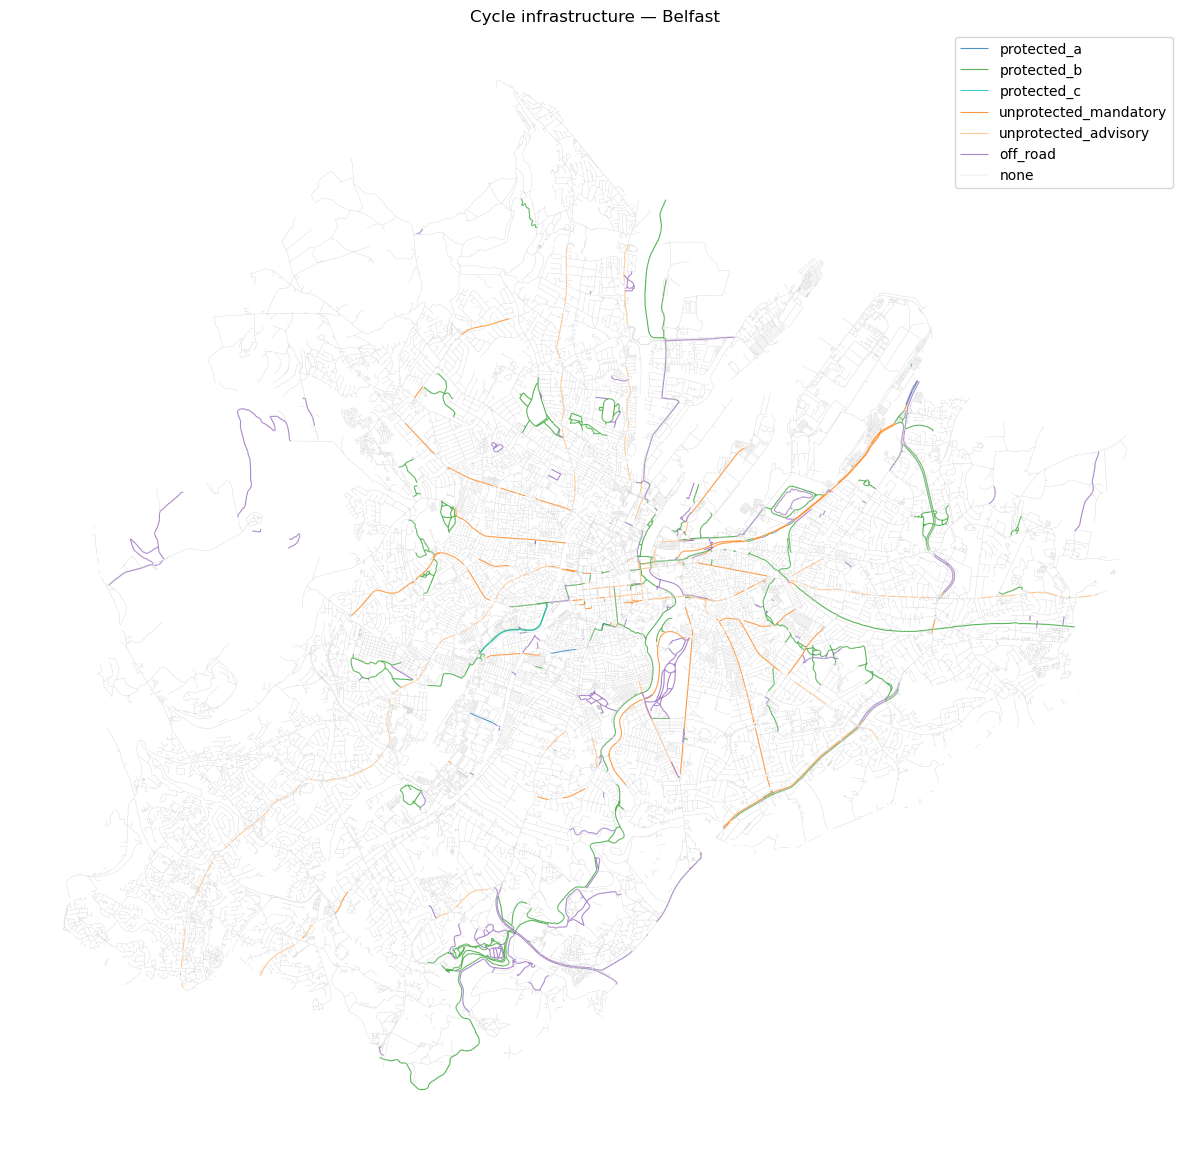

In [16]:
# Sanity check: visualise a small area
if edges is not None:
    bbox_bng = edges.total_bounds  
    cc_edges = edges.cx[bbox_bng[0]:bbox_bng[2], bbox_bng[1]:bbox_bng[3]]

    colour_map = {
        'protected_a': '#1f77b4',
        'protected_b': '#2ca02c',
        'protected_c': '#17becf',
        'unprotected_mandatory': '#ff7f0e',
        'unprotected_advisory': '#ffbb78',
        'off_road': '#9467bd',
        'none': '#cccccc',
    }

    fig, ax = plt.subplots(figsize=(12, 12))
    for cat, colour in colour_map.items():
        subset = cc_edges[cc_edges['cycle_infra'] == cat]
        if len(subset) > 0:
            subset.plot(ax=ax, color=colour, linewidth=0.8 if cat != 'none' else 0.3,
                       label=cat, alpha=0.8)
    
    ax.legend(loc='upper right')
    ax.set_title('Cycle infrastructure — Belfast')
    ax.set_axis_off()
    plt.tight_layout()

    # bbox_inches='tight' removes excess white space around the edges
    plt.savefig(OUTPUT_DIR / 'Belfast_cycle_infrastructure.png', dpi=500, bbox_inches='tight')
    
    # Optional: still display the plot in your IDE/notebook
    plt.show()


## Level of Traffic Stress
### LTS Conveyal Original
The [Conveyal Estimated LTS scheme](https://docs.conveyal.com/learn-more/traffic-stress) (Conveyal 2015) is a sequential rule-based implementation of the Mekuria et al. (2012) methodology, adapted for contexts where only standard OpenStreetMap tags are available. It prioritises physical road attributes and applies conservative inference rules where data is incomplete, trading some precision for broad network coverage.

**Core Principles:**

1. **Physical Parameter Dependency**: LTS values are derived from the interaction between posted speed limits, lane counts, and the presence of cycling infrastructure tags. These three variables form the primary decision matrix for all non-residential roads.

2. **Conservative Inference for Missing Data**: Where critical tags such as `maxspeed` or `lanes` are absent, the model applies road-class-specific defaults rather than leaving segments unassigned. For example, tertiary roads with unknown speed and fewer than four lanes default to LTS 2, reflecting the assumption that minor roads are unlikely to be high-speed. Only `highway=service` segments are deliberately left unclassified, to prevent stress levels from service lanes bleeding into adjacent streets.

3. **Unsignalised Intersection Adjustment**: After per-edge classification, a second pass propagates stress levels at junctions. At each vertex without a traffic signal tag, the maximum LTS of all incident edges is assigned to every connecting edge. This reflects the crossing difficulty experienced at uncontrolled intersections on otherwise low-stress routes. Signalised intersections are treated as neutral and excluded from this adjustment.

**Classification Procedure:**

The scheme operates as a sequential decision tree applied to each edge independently, followed by a network-level intersection adjustment.

**Table a — [Conveyal LTS Base Classification Sequent Rules (from Conveyal Github Repo)](https://github.com/conveyal/analysis-backend/blob/v5.9.0/src/main/java/com/conveyal/r5/labeling/LevelOfTrafficStressLabeler.java) (Initial Round)**

| Priority | Condition | LTS Assigned |
|----------|-----------|--------------|
| 1 | Explicit `lts` tag present in source data | Value of tag (1–4) |
| 2 | Motor vehicles prohibited (no `ALLOWS_CAR` flag) | 1 |
| 3 | `highway = service` | Unclassified (intentional) |
| 4 | `highway = residential` or `living_street` | 1 |
| 5 | `maxspeed ≤ 25 mph` AND lanes ≤ 3 or unknown | Default = LTS 2 |
| 6 | `highway = tertiary` / `unclassified` / `tertiary_link`, lanes ≤ 3, speed unknown | Default = LTS 2 |
| 7 | Above road classes + cycling infrastructure present | 2 |
| 8 | Other roads (`primary`, `secondary`, `trunk`) + cycling infrastructure | Default LTS (2 or 3) |
| 9 | No condition matched | 4 |

*Note: "cycling infrastructure present" refers to `cycleway=lane`, `cycleway:left/right=lane`, or equivalent directional tags. Default LTS in rows 5–8 is 2 if the road is slow (≤ 25 mph) with few or unknown lanes, otherwise 3.*

**Table b — Speed × Lane Count Decision Matrix (Non-Residential, Non-Tertiary Roads)**

| | Lanes ≤ 3 | Lanes ≥ 4 | Lanes unknown |
|---|---|---|---|
| Speed ≤ 25 mph | Default LTS **2** | Default LTS **3** | Default LTS **2** |
| Speed > 25 mph | Default LTS **3** | Default LTS **3** | Default LTS **3** |
| Speed unknown | Default LTS **3** | Default LTS **3** | Default LTS **3** |

*This default is then overridden upward or downward by the presence of cycling infrastructure and road class (see Table 4.1).*

**Table c — Unsignalised Intersection Adjustment**

| Vertex condition | Action |
|---|---|
| Has `traffic_signal` tag | No adjustment; vertex excluded |
| No signal tag | All incident edges reassigned to max LTS among all incident edges |

*This step may produce counterintuitive results: a dedicated cycleway (LTS 1) crossing an LTS 4 arterial will be relabelled LTS 4 on both approach segments, even though the path itself provides physical separation. This is a known limitation of the original Conveyal scheme.*

**Limitations:**

The original scheme has two notable constraints relevant to this study. First, the directional assignment of cycling infrastructure (distinguishing `cycleway:right=lane` from `cycleway:left=lane`) is simplified in Python implementations that process undirected edges, potentially misassigning LTS on one-way streets or contraflow lanes. Second, the intersection adjustment can substantially reduce the apparent extent of low-stress networks in dense urban areas, where low-stress paths frequently cross arterials, as documented by Mekuria et al. (2012) and discussed further in Section 4.3.

In [23]:
# Extract traffic signals separately from POI/points layer
traffic_signals = osm.get_pois(
    custom_filter={'highway': ['traffic_signals']}
)

if traffic_signals is not None:
    traffic_signals = traffic_signals.to_crs(CRS_IG)
    traffic_signals = gpd.clip(traffic_signals, belfast_zones)
    print(f"Traffic signal nodes: {len(traffic_signals):,}")

Traffic signal nodes: 1,298


In [24]:
from collections import Counter
import numpy as np
from shapely.geometry import MultiLineString

def geom_to_endpoints(geom):
    """Extract start and end points, handling both LineString and MultiLineString."""
    if geom.geom_type == 'MultiLineString':
        # For MultiLineString, use first point of first line and last point of last line
        coords_start = list(geom.geoms[0].coords)
        coords_end   = list(geom.geoms[-1].coords)
        start = tuple(np.round(coords_start[0], 2))
        end   = tuple(np.round(coords_end[-1], 2))
    else:
        coords = list(geom.coords)
        start  = tuple(np.round(coords[0],  2))
        end    = tuple(np.round(coords[-1], 2))
    return start, end

endpoints = edges['geometry'].apply(geom_to_endpoints)

all_nodes = []
for start, end in endpoints:
    all_nodes.append(start)
    all_nodes.append(end)

node_counts     = Counter(all_nodes)
total_nodes     = len(node_counts)
intersections   = {n: c for n, c in node_counts.items() if c >= 3}
n_intersections = len(intersections)

print(f"Total unique nodes          : {total_nodes:,}")
print(f"True intersections (deg ≥ 3): {n_intersections:,}")
print(f"Signal coverage             : {len(traffic_signals) / n_intersections * 100:.1f}%")

Total unique nodes          : 36,294
True intersections (deg ≥ 3): 2,619
Signal coverage             : 49.6%


In [26]:
# ── Constants ──────────────────────────────────────────────────────────────────
SPEED_THRESHOLD_KMH = 25 * 1.609   # 25 mph -> ~40.23 km/h
LANE_THRESHOLD      = 3
MISSING_LANES       = 999
traffic_signals = traffic_signals.to_crs(edges.crs)

NO_CAR_HIGHWAYS = {
    'cycleway', 'path', 'footway', 'pedestrian', 'track', 'bridleway'
}

ROUTINO_FALLBACK_LTS: dict[str, int] = {
    'cycleway': 1, 'path': 1, 'track': 1, 'living_street': 1,
    'footway': 1, 'pedestrian': 1,
    'service': 2, 'bridleway': 2,
    'steps': 3, 'secondary': 3,
    'primary': 4, 'primary_link': 4, 'trunk': 4, 'trunk_link': 4,
}


# ── Step 1: Speed Parser ──────────────────────────────────────────────────────
def get_speed_kmh(maxspeed_tag) -> float:
    if pd.isna(maxspeed_tag) or str(maxspeed_tag).strip() == '':
        return np.nan
    s = str(maxspeed_tag).lower().strip()
    m = re.match(r'^([0-9][\.0-9]*?) ?(km/h|kmh|kph|mph|knots)?$', s)
    if not m:
        return np.nan
    val, unit = float(m.group(1)), m.group(2)
    if unit == 'mph':    return val * 1.609
    if unit == 'knots':  return val * 1.852
    return val


# ── Step 2: Conveyal Per-Edge LTS ─────────────────────────────────────────────
def calculate_lts(row) -> int | None:
    highway     = str(row.get('highway',     '')).lower().strip()
    cycle_infra = str(row.get('cycle_infra', 'none')).lower().strip()

    if highway in NO_CAR_HIGHWAYS:                  return 1
    if highway == 'service':                        return None
    if highway in ('residential', 'living_street'): return 1

    speed_kmh = get_speed_kmh(row.get('maxspeed'))
    try:
        lanes = int(float(row.get('lanes'))) if pd.notnull(row.get('lanes')) else MISSING_LANES
    except (ValueError, TypeError):
        lanes = MISSING_LANES

    slow_road     = (not np.isnan(speed_kmh)) and (speed_kmh <= SPEED_THRESHOLD_KMH)
    unknown_speed = np.isnan(speed_kmh)
    few_lanes     = lanes <= LANE_THRESHOLD
    unknown_lanes = lanes == MISSING_LANES

    default_lts = 3
    if slow_road and (few_lanes or unknown_lanes):  default_lts = 2
    elif few_lanes and unknown_speed:               default_lts = 2

    if highway in ('unclassified', 'tertiary', 'tertiary_link'):
        if unknown_lanes and slow_road:   default_lts = 2
        if cycle_infra in ('protected_a', 'unprotected_mandatory', 'unprotected_advisory'):
            return 2
        return default_lts

    if cycle_infra in ('protected_a', 'unprotected_mandatory', 'unprotected_advisory'):
        return default_lts

    return 4


# ── Step 3: Cyclability Filter ────────────────────────────────────────────────
def is_cyclable(row) -> bool:
    highway = str(row.get('highway', '')).lower().strip()
    if highway in {'motorway', 'motorway_link', 'proposed', 'construction', 'abandoned', 'platform'}:
        return False
    service_type = str(row.get('service', '')).lower().strip()
    if highway == 'service' and service_type in {
        'parking_aisle', 'driveway', 'drive-through', 'car_wash', 'garages'
    }:
        return False
    if str(row.get('bicycle', '')).lower().strip() in ('no', 'private', 'restricted'):
        return False
    return True


# ── Step 4: Cycle Infrastructure Override ─────────────────────────────────────
def apply_cycle_infra_override(edges: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    ci = edges['cycle_infra'].str.lower().str.strip()
    fully_protected = ci.isin(['protected_b', 'protected_c', 'off_road'])
    adjacent_track  = ci == 'protected_a'
    edges.loc[fully_protected, 'lts'] = 1
    edges.loc[adjacent_track,  'lts'] = 2
    print(f"  protected_b/c/off_road -> LTS 1 : {fully_protected.sum():,} edges")
    print(f"  protected_a            -> LTS 2 : {adjacent_track.sum():,} edges")
    return edges


# ── Step 5: Routino Highway Fallback ──────────────────────────────────────────
def apply_routino_fallback(edges: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    mask = edges['lts'].isna()
    if mask.sum() == 0:
        print("  No unclassified edges.")
        return edges
    fallback = edges.loc[mask, 'highway'].str.lower().str.strip().map(ROUTINO_FALLBACK_LTS)
    edges.loc[mask, 'lts'] = fallback
    print(f"  Filled : {fallback.notna().sum():,}  |  Still NaN : {edges['lts'].isna().sum():,}")
    return edges


# ── Shared Helper: Extract Endpoints ──────────────────────────────────────────
def _endpoints(geom):
    if geom.geom_type == 'MultiLineString':
        return (tuple(np.round(list(geom.geoms[0].coords)[0],   2)),
                tuple(np.round(list(geom.geoms[-1].coords)[-1], 2)))
    c = list(geom.coords)
    return tuple(np.round(c[0], 2)), tuple(np.round(c[-1], 2))


def _build_vertex_edge_map(edges):
    ve = defaultdict(list)
    for idx, row in edges.iterrows():
        s, e = _endpoints(row.geometry)
        ve[s].append(idx); ve[e].append(idx)
    return {c: e for c, e in ve.items() if len(e) >= 3}


# ── Step 6: Conveyal Intersection Adjustment ──────────────────────────────────
def apply_conveyal_intersection_adjustment(edges: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    assert edges.crs is not None, "edges must have a projected CRS"

    intersections = _build_vertex_edge_map(edges)
    edges      = edges.copy()
    lts_series = edges['lts'].copy()
    n_upgraded = 0

    for _, edge_idxs in intersections.items():
        vals = [lts_series[i] for i in edge_idxs if pd.notnull(lts_series[i])]
        if not vals: continue
        mx = max(vals)
        for i in edge_idxs:
            if pd.notnull(lts_series[i]) and mx > lts_series[i]:
                lts_series[i] = mx; n_upgraded += 1

    edges['lts'] = lts_series
    print(f"  Intersections : {len(intersections):,}  |  Edges upgraded : {n_upgraded:,}")
    return edges


# ── Step 7: Jeong & Smith Signalised Intersection Adjustment ──────────────────
def apply_jeong_smith_intersection(
    edges: gpd.GeoDataFrame,
    traffic_signals: gpd.GeoDataFrame,
    signal_buffer_m: float = 15.0,
) -> gpd.GeoDataFrame:
    assert edges.crs is not None, "edges must have a projected CRS"
    assert edges.crs == traffic_signals.crs, "CRS mismatch between edges and signals"

    intersections  = _build_vertex_edge_map(edges)
    sig_geoms      = traffic_signals.geometry.values
    sig_sindex     = traffic_signals.sindex

    def is_signalised(xy):
        pt = Point(xy)
        cands = list(sig_sindex.intersection(pt.buffer(signal_buffer_m).bounds))
        return any(sig_geoms[i].distance(pt) <= signal_buffer_m for i in cands)

    edges      = edges.copy()
    lts_series = edges['lts'].copy()
    n_unsig = n_sig = n_reduced = 0

    for coord, edge_idxs in intersections.items():
        vals = [lts_series[i] for i in edge_idxs if pd.notnull(lts_series[i])]
        if not vals: continue
        mx = max(vals)

        if is_signalised(coord):
            n_sig += 1
            mn = min(vals)
            if mx <= 2:                    jlts = 1;      n_reduced += 1
            elif mn <= 2 and mx >= 3:      jlts = mx - 1; n_reduced += 1
            else:                          jlts = mx
        else:
            n_unsig += 1; jlts = mx

        for i in edge_idxs:
            if pd.notnull(lts_series[i]) and jlts > lts_series[i]:
                lts_series[i] = jlts

    edges['lts'] = lts_series
    print(f"  Intersections : {len(intersections):,}")
    print(f"  Unsignalised  : {n_unsig:,}  |  Signalised : {n_sig:,}  |  Reduced : {n_reduced:,}")
    return edges


# ── Diagnostics Helper ────────────────────────────────────────────────────────
def print_lts_dist(edges, mask, label):
    d = edges.loc[mask, 'lts'].value_counts().sort_index()
    print(f"\n-- {label} --")
    for k in [1.0, 2.0, 3.0, 4.0]:
        print(f"  LTS {int(k)} : {d.get(k,0):>8,}")
    print(f"  None  : {edges.loc[mask,'lts'].isna().sum():>8,}")


# ── Execute Pipeline ──────────────────────────────────────────────────────────
if edges is not None:

    # Step 2
    edges['lts'] = np.nan
    cyclable_mask = edges.apply(is_cyclable, axis=1)
    edges.loc[cyclable_mask, 'lts'] = edges[cyclable_mask].apply(calculate_lts, axis=1)
    total = cyclable_mask.sum()
    print(f"Cyclable edges : {total:,}  |  "
          f"Labeled : {edges.loc[cyclable_mask,'lts'].notna().sum():,}  |  "
          f"Unlabeled : {edges.loc[cyclable_mask,'lts'].isna().sum():,}")
    print_lts_dist(edges, cyclable_mask, "Step 2 - Base Conveyal per-edge")

    # Step 4
    print("\n-- Step 4 - Jeong & Smith cycle infrastructure override --")
    edges = apply_cycle_infra_override(edges)

    # Step 5
    print("\n-- Step 5 - Routino highway fallback --")
    edges = apply_routino_fallback(edges)
    print_lts_dist(edges, cyclable_mask, "After Steps 4+5 (Pre-Intersection Baseline)")

    # Snapshot before intersection passes
    edges['lts_pre_intersection'] = edges['lts'].copy()

    # Step 6
    print("\n-- Step 6 - Conveyal intersection adjustment (For Comparison) --")
    edges_conveyal = apply_conveyal_intersection_adjustment(edges.copy())
    edges['lts_conveyal_intersection'] = edges_conveyal['lts']
    print_lts_dist(edges, cyclable_mask, "After Step 6 - Strict Conveyal intersection")

    # Step 7
    print("\n-- Step 7 - Jeong & Smith signalised intersection adjustment --")
    edges['lts'] = edges['lts_pre_intersection'].copy()
    edges = apply_jeong_smith_intersection(edges, traffic_signals)
    print_lts_dist(edges, cyclable_mask, "After Step 7 - Jeong & Smith intersection")

    # Final comparison
    conveyal = edges.loc[cyclable_mask, 'lts_conveyal_intersection'].value_counts().sort_index()
    jeong    = edges.loc[cyclable_mask, 'lts'].value_counts().sort_index()
    print(f"\n-- Diagnostics: Conveyal vs Jeong & Smith (Network Difference) --")
    print(f"{'LTS':<8} {'Conveyal':>10} {'Jeong&Smith':>12} {'Change':>10}")
    print("-" * 44)
    for k in [1.0, 2.0, 3.0, 4.0]:
        c = conveyal.get(k, 0); j = jeong.get(k, 0)
        print(f"LTS {int(k):<4} {c:>10,} {j:>12,} {j-c:>+10,}") 

Cyclable edges : 19,599  |  Labeled : 13,849  |  Unlabeled : 5,750

-- Step 2 - Base Conveyal per-edge --
  LTS 1 :   10,459
  LTS 2 :      387
  LTS 3 :    1,590
  LTS 4 :    1,413
  None  :    5,750

-- Step 4 - Jeong & Smith cycle infrastructure override --
  protected_b/c/off_road -> LTS 1 : 1,059 edges
  protected_a            -> LTS 2 : 7 edges

-- Step 5 - Routino highway fallback --
  Filled : 9,614  |  Still NaN : 0

-- After Steps 4+5 (Pre-Intersection Baseline) --
  LTS 1 :   10,468
  LTS 2 :    6,138
  LTS 3 :    1,589
  LTS 4 :    1,404
  None  :        0

-- Step 6 - Conveyal intersection adjustment (For Comparison) --
  Intersections : 2,619  |  Edges upgraded : 1,609

-- After Step 6 - Strict Conveyal intersection --
  LTS 1 :   10,468
  LTS 2 :    6,138
  LTS 3 :    1,589
  LTS 4 :    1,404
  None  :        0

-- Step 7 - Jeong & Smith signalised intersection adjustment --
  Intersections : 2,619
  Unsignalised  : 2,326  |  Signalised : 293  |  Reduced : 138

-- After 

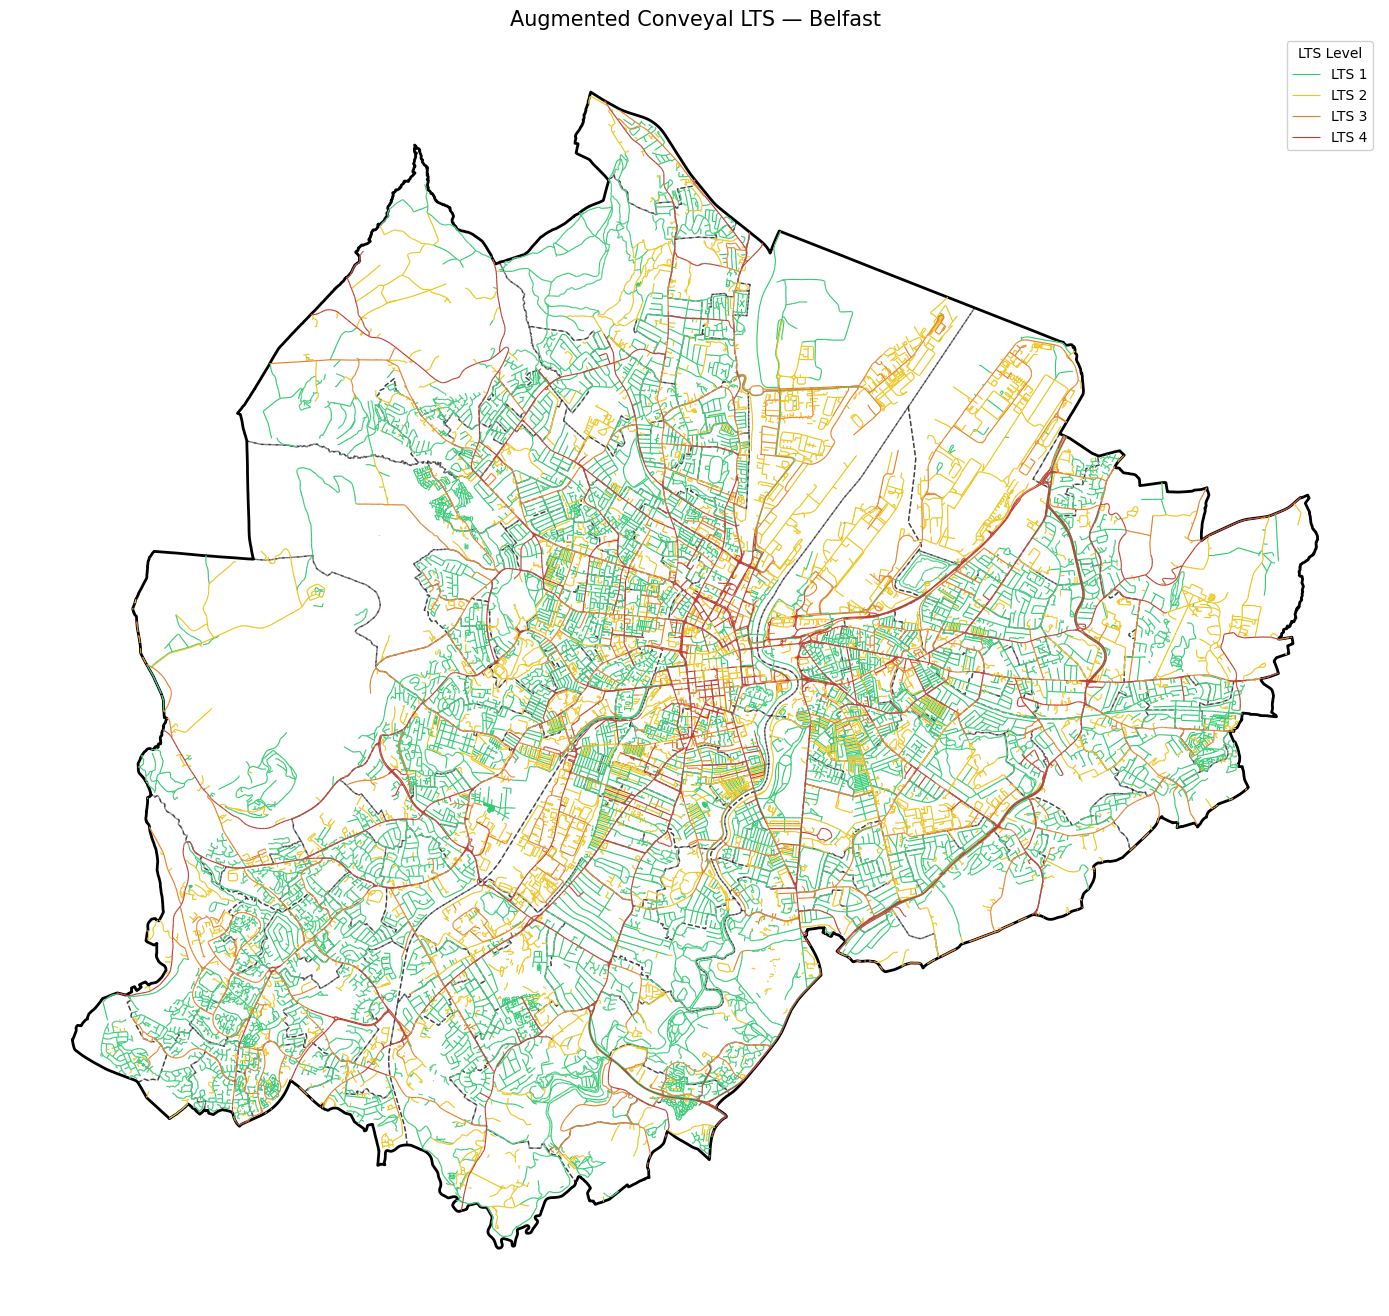

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

# Plot study area boundary
study_area.to_crs(edges.crs).plot(
    ax=ax, facecolor='none', edgecolor='black',
    linewidth=1, linestyle='--', alpha = 0.5, zorder=0, label='Study area boundary'
)

gpd.GeoDataFrame(geometry=[belfast_boundary], crs=study_area.crs).to_crs(edges.crs).plot(
    ax=ax, facecolor='none', edgecolor='black',
    linewidth=2, linestyle='-', alpha=1, zorder=0
)

# Base network
plot_gdf.plot(ax=ax, color='#eeeeee', linewidth=0.5, zorder=1)

# LTS layers
color_map = {
    'LTS 1': '#2ecc71',
    'LTS 2': '#f1c40f',
    'LTS 3': '#e67e22',
    'LTS 4': '#c0392b',
    'Missing (Service)': '#9b59b6',
}
for status, color in color_map.items():
    subset = plot_gdf[plot_gdf['lts_status'] == status]
    if not subset.empty:
        subset.plot(ax=ax, color=color, linewidth=0.8, label=status,
                    zorder=3 if 'Missing' in status else 2)

ax.set_title("Augmented Conveyal LTS — Belfast", fontsize=15)
ax.legend(title="LTS Level", loc='upper right', framealpha=0.9)
ax.axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Belfast_LTS.png', dpi=500, bbox_inches='tight')
plt.show()
